## Flight Departure Delay Prediction using Apache Spark MLlib
- Authors: Maryam Mahaboob and Amina Baziz
- Course: DSAI4202, UDST
- Goal: predict whether a US domestic flight will depart 15 or more minutes late
- Dataset: 7,079,081 flight records from 2024 with 35 columns
- Tool: Apache Spark MLlib on Google Colab
- Models compared: Logistic Regression, Random Forest, Gradient Boosted Trees
- Key techniques used: cyclical encoding, class imbalance handling, hyperparameter tuning, threshold optimization, feature selection
- Dataset Link: https://www.kaggle.com/datasets/hrishitpatil/flight-data-2024?select=flight_data_2024_sample.csv

## Environment Setup, Import & Data Loading

In [ ]:
!pip install pyspark -q

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("FlightDelays2024") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

print("Spark ready:", spark.version)

Spark ready: 4.0.2


In [ ]:
from google.colab import drive
from pyspark.sql.functions import when, col
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql.functions import col, avg, count, atan2, lit
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pyspark.sql.functions import sin, cos, when, col
import math
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.sql.functions import when, col
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.sql.functions import udf, col
from pyspark.sql.types import DoubleType
import numpy as np
import matplotlib.pyplot as plt
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.sql.functions import col, udf
from pyspark.sql.types import DoubleType
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
drive.mount('/content/drive')

df = spark.read.csv(
    "/content/drive/MyDrive/DSAI4202_Project/flight_data_2024.csv",
    header=True, inferSchema=True
)

print("Rows:", df.count())
print("Columns:", len(df.columns))
df.printSchema()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rows: 7079081
Columns: 35
root
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day_of_month: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- fl_date: date (nullable = true)
 |-- op_unique_carrier: string (nullable = true)
 |-- op_carrier_fl_num: double (nullable = true)
 |-- origin: string (nullable = true)
 |-- origin_city_name: string (nullable = true)
 |-- origin_state_nm: string (nullable = true)
 |-- dest: string (nullable = true)
 |-- dest_city_name: string (nullable = true)
 |-- dest_state_nm: string (nullable = true)
 |-- crs_dep_time: integer (nullable = true)
 |-- dep_time: double (nullable = true)
 |-- dep_delay: double (nullable = true)
 |-- taxi_out: double (nullable = true)
 |-- wheels_off: double (nullable = true)
 |-- wheels_on: double (nullable = true)
 |-- taxi_in: double (nullable =

## Data Preprocessing

In [ ]:
cols_needed = [
    "month", "day_of_week", "day_of_month",
    "op_unique_carrier", "origin", "dest",
    "dep_delay", "distance", "crs_elapsed_time",
    "crs_dep_time", "cancelled"
]

df = df.select(cols_needed)
df = df.filter(df.cancelled == 0).drop("cancelled")
print("After filter:", df.count())

After filter: 4875668


In [ ]:
df = df.sample(fraction=0.7, seed=42)

fill_cols = ["carrier_delay", "weather_delay", "nas_delay",
             "security_delay", "late_aircraft_delay"]
df = df.dropna(subset=["dep_delay", "distance", "crs_elapsed_time"])
print("Final rows:", df.count())

Final rows: 1673114


In [ ]:
# Target label
df = df.withColumn("label", when(col("dep_delay") >= 15, 1).otherwise(0))

In [ ]:
# Cyclical encoding
df = df.withColumn("month_sin", sin(col("month") * (2 * math.pi / 12))) \
       .withColumn("month_cos", cos(col("month") * (2 * math.pi / 12))) \
       .withColumn("dow_sin", sin(col("day_of_week") * (2 * math.pi / 7))) \
       .withColumn("dow_cos", cos(col("day_of_week") * (2 * math.pi / 7))) \
       .drop("month", "day_of_week")

# day of month cyclical
df = df.withColumn("day_of_month_sin", sin(col("day_of_month") * (2 * math.pi / 31))) \
       .withColumn("day_of_month_cos", cos(col("day_of_month") * (2 * math.pi / 31))) \
       .drop("day_of_month")

df = df.withColumn("dep_time_sin", sin(col("crs_dep_time") * (2 * math.pi / 2400))) \
       .withColumn("dep_time_cos", cos(col("crs_dep_time") * (2 * math.pi / 2400))) \
       .drop("crs_dep_time")
df.show(5)

+-----------------+------+----+---------+--------+----------------+-----+-------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+--------------------+
|op_unique_carrier|origin|dest|dep_delay|distance|crs_elapsed_time|label|          month_sin|         month_cos|           dow_sin|           dow_cos|   day_of_month_sin|  day_of_month_cos|       dep_time_sin|        dep_time_cos|
+-----------------+------+----+---------+--------+----------------+-----+-------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+--------------------+
|               9E|   JFK| DTW|     -5.0|   509.0|           136.0|    0|0.49999999999999994|0.8660254037844387|0.7818314824680298|0.6234898018587336|0.20129852008866006|0.9795299412524945|-0.1357155724343038| -0.9907478404714437|
|               9E|   MSP| CLE|    -14.0|   622.0|           130.0|    0|0.4

## Preprocessing Insights
- Started with 7,079,081 rows and selected 10 feature columns plus the cancelled flag used for filtering
- Removed cancelled flights since they have no departure delay value, leaving 4,875,668 records
- Sampled 70% for computational feasibility while keeping enough data for reliable results
- Dropped nulls only on dep_delay, distance, and crs_elapsed_time to avoid removing too many rows
- Final dataset: 1,673,114 rows
- Target label: 1 if dep_delay is 15 or more minutes, 0 otherwise
- Correlation heatmap showed distance and crs_elapsed_time have a 0.98 correlation so crs_elapsed_time was dropped to remove redundancy
- Mean departure delay is 12.6 minutes, max is 3024 minutes which indicates some extreme outliers
- Average flight distance is 833 miles with a standard deviation of 596 miles

## EDA

In [ ]:
# Sample small portion just for plotting
df_plot = df.sample(fraction=0.01, seed=42).toPandas()
df_sample = df.sample(fraction=0.01, seed=42).toPandas()

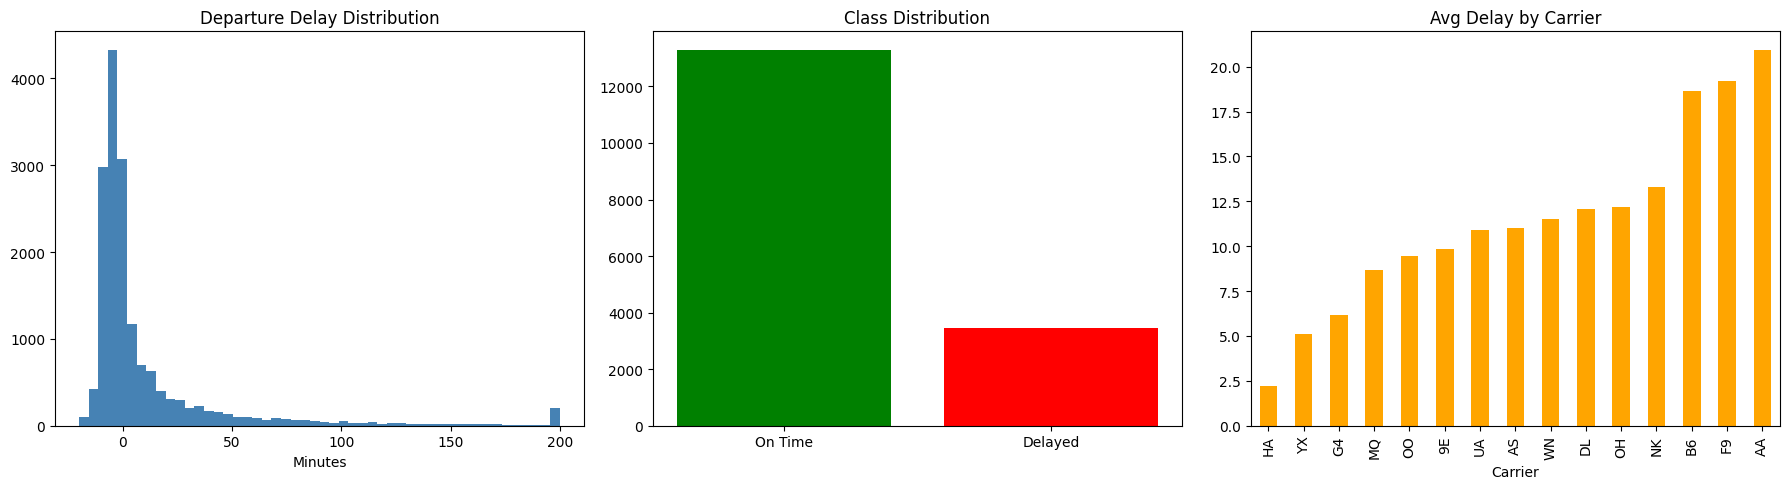

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot: Delay distribution
axes[0].hist(df_plot["dep_delay"].clip(-20, 200), bins=50, color="steelblue")
axes[0].set_title("Departure Delay Distribution")
axes[0].set_xlabel("Minutes")

# Plot: Delayed vs Not Delayed
label_counts = df_plot["label"].value_counts()
axes[1].bar(["On Time", "Delayed"], label_counts.values, color=["green", "red"])
axes[1].set_title("Class Distribution")

# Plot: Avg delay by carrier
df_plot.groupby("op_unique_carrier")["dep_delay"].mean().sort_values().plot(
    kind="bar", ax=axes[2], color="orange"
)
axes[2].set_title("Avg Delay by Carrier")
axes[2].set_xlabel("Carrier")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/DSAI4202_Project/eda_plots.png")
plt.show()

## Insights

**Departure Delay Distribution:**
- The distribution is extremely right skewed, most flights depart on time or even a few minutes early
- There is a big spike around 0 minutes showing the majority of flights have very small delays or none at all
- There are some extreme outliers going up to 200+ minutes but these are rare
- This tells us that predicting delays is genuinely hard because most of the data is on-time flights

**Class Distribution:**
- On time flights heavily outnumber delayed flights
- We have 1,328,820 on-time flights vs 344,294 delayed flights, a ratio of about 3.86 to 1
- This imbalance means any model that just always predicts on-time would get 79% accuracy without learning anything useful
- This is why we applied class weights during training

**Average Delay by Carrier:**
- YX has the lowest average delay at around 3.5 minutes, and HA (Hawaiian Airlines) is also low at around 6.7 minutes, likely because Hawaii routes are less congested
- AA (American Airlines) and F9 (Frontier) have the highest average delays at around 20 minutes
- Budget carriers like F9 tend to have tighter turnaround schedules which causes delays to stack up
- This shows carrier choice is genuinely related to delay patterns which is why carrier_idx ended up being an important feature

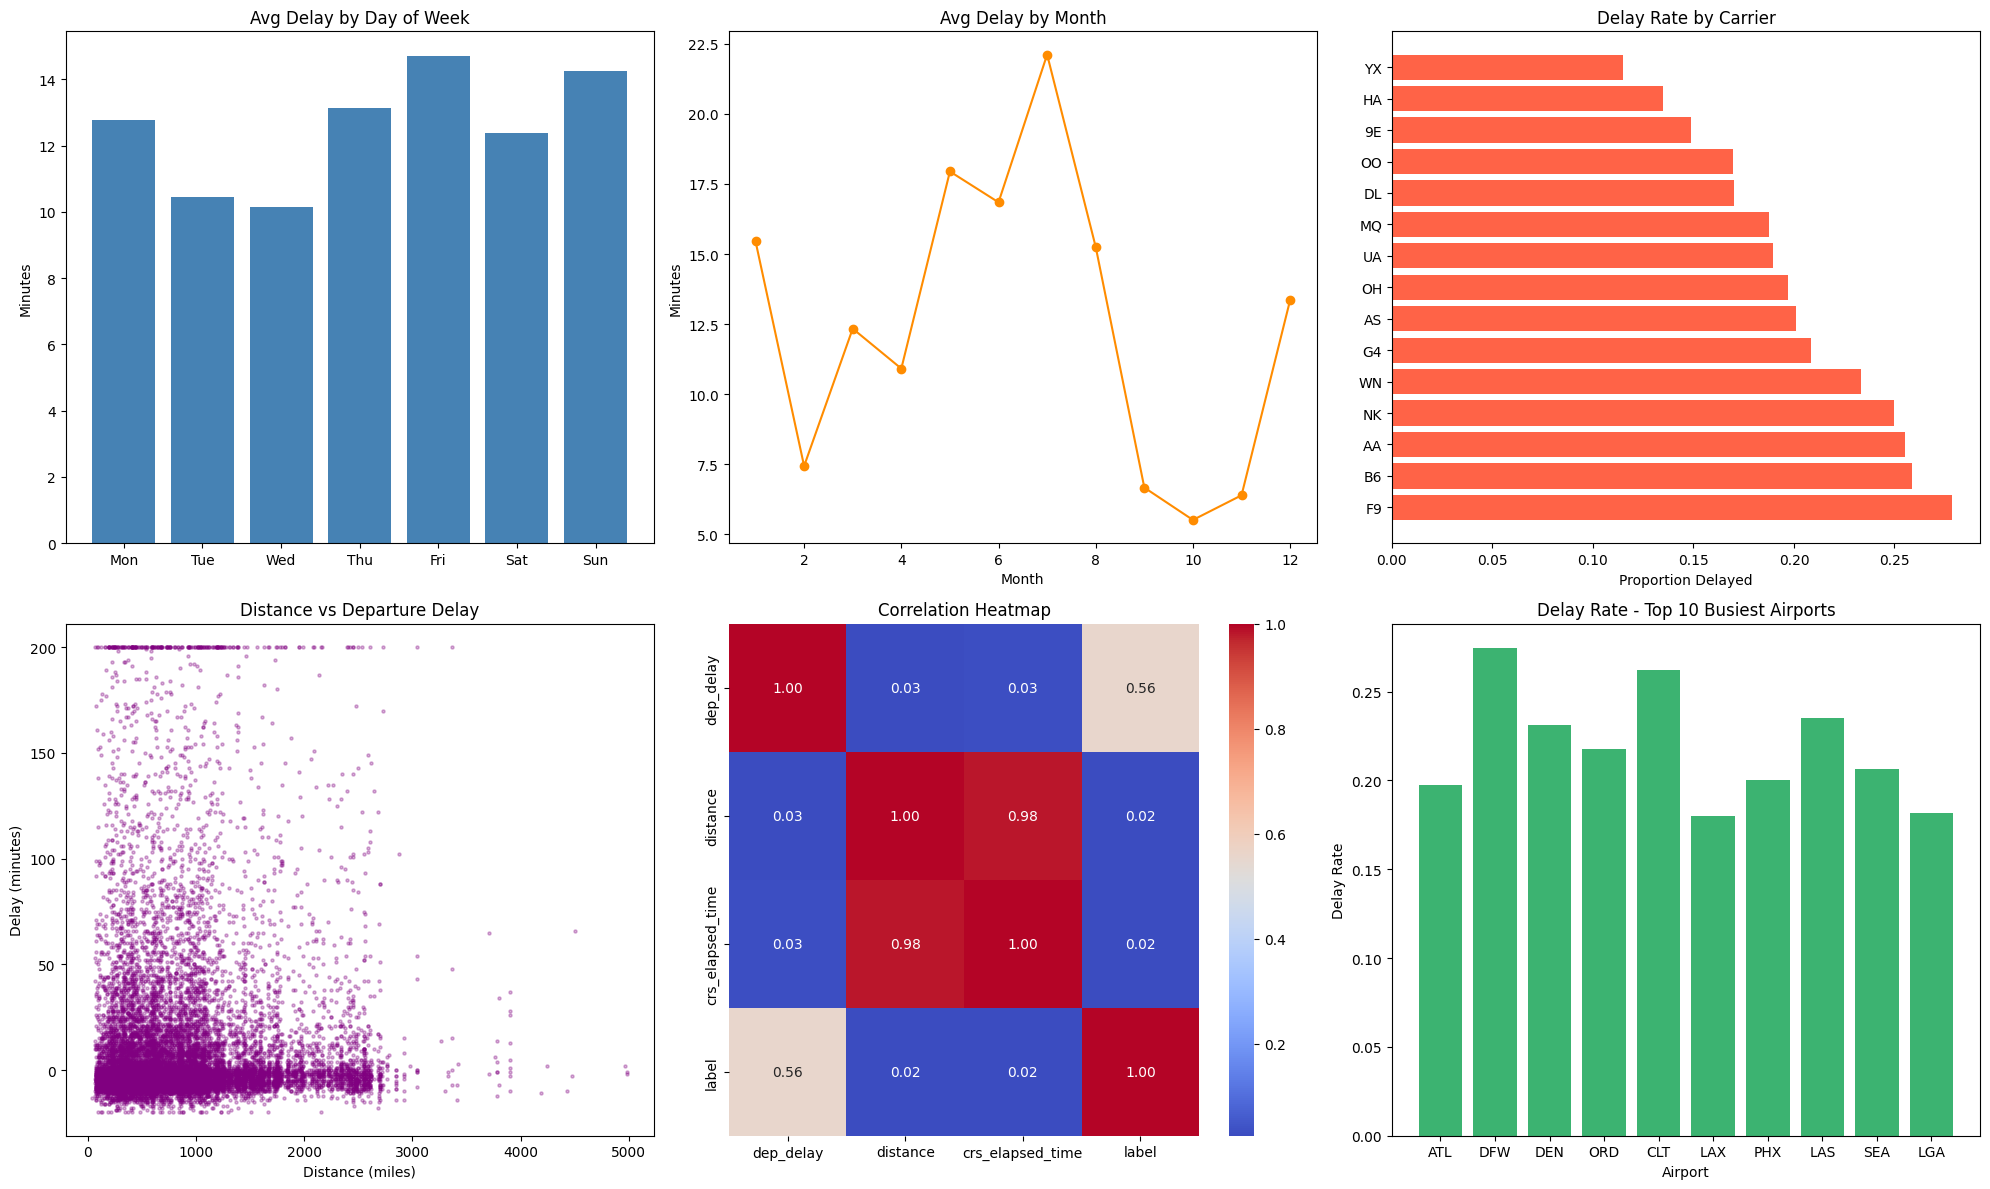

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Delay by day of week
dow_avg = df.groupBy("dow_sin", "dow_cos").agg(avg("dep_delay").alias("avg_delay")).toPandas()
dow_avg["dow"] = np.round(np.arctan2(dow_avg["dow_sin"], dow_avg["dow_cos"]) / (2 * np.pi / 7) % 7).astype(int)
dow_avg = dow_avg.groupby("dow")["avg_delay"].mean().sort_index()
axes[0,0].bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], dow_avg.values, color="steelblue")
axes[0,0].set_title("Avg Delay by Day of Week")
axes[0,0].set_ylabel("Minutes")

# Delay by month
month_avg = df.groupBy("month_sin", "month_cos").agg(avg("dep_delay").alias("avg_delay")).toPandas()
month_avg["month"] = np.round(np.arctan2(month_avg["month_sin"], month_avg["month_cos"]) / (2 * np.pi / 12) % 12).astype(int)
month_avg["month"] = month_avg["month"].replace(0, 12)
month_avg = month_avg.groupby("month")["avg_delay"].mean().sort_index()
axes[0,1].plot(month_avg.index, month_avg.values, marker="o", color="darkorange")
axes[0,1].set_title("Avg Delay by Month")
axes[0,1].set_xlabel("Month")
axes[0,1].set_ylabel("Minutes")

# Delay rate by carrier
carrier_stats = df.groupBy("op_unique_carrier").agg(
    avg("label").alias("delay_rate"),
    count("*").alias("total_flights")
).filter(col("total_flights") > 1000).toPandas().sort_values("delay_rate", ascending=False)
axes[0,2].barh(carrier_stats["op_unique_carrier"], carrier_stats["delay_rate"], color="tomato")
axes[0,2].set_title("Delay Rate by Carrier")
axes[0,2].set_xlabel("Proportion Delayed")

# Distance vs delay
axes[1,0].scatter(df_sample["distance"], df_sample["dep_delay"].clip(-20, 200), alpha=0.3, s=5, color="purple")
axes[1,0].set_title("Distance vs Departure Delay")
axes[1,0].set_xlabel("Distance (miles)")
axes[1,0].set_ylabel("Delay (minutes)")

# Correlation heatmap
num_cols = ["dep_delay", "distance", "crs_elapsed_time", "label"]
corr_matrix = df_sample[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1,1])
axes[1,1].set_title("Correlation Heatmap")

# Top 10 busiest airports delay rate
airport_stats = df.groupBy("origin").agg(
    avg("label").alias("delay_rate"),
    count("*").alias("flights")
).orderBy(col("flights").desc()).limit(10).toPandas()
axes[1,2].bar(airport_stats["origin"], airport_stats["delay_rate"], color="mediumseagreen")
axes[1,2].set_title("Delay Rate - Top 10 Busiest Airports")
axes[1,2].set_xlabel("Airport")
axes[1,2].set_ylabel("Delay Rate")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/DSAI4202_Project/eda_extended.png")
plt.show()

## Insights


**Average Delay by Day of Week:**
- Friday has the highest average delay at around 14 to 15 minutes
- Tuesday and Wednesday have the lowest delays around 10 minutes
- This makes sense because Friday is the peak travel day, airports are more crowded, and delays from earlier in the day compound by evening
- Saturday and Sunday are also higher than midweek, consistent with weekend travel spikes

**Average Delay by Month:**
- July has the highest average delay at around 22 minutes, this matches the summer travel peak in the US
- February has very low delays around 7 to 8 minutes which is surprising but may reflect reduced travel volume
- October and November are consistently the lowest delay months, airlines operate more smoothly in fall
- December starts climbing again due to holiday travel
- This seasonal pattern is exactly why we included month as a feature

**Distance vs Departure Delay:**
- The scatter plot shows no clear linear relationship between distance and delay
- Short and long haul flights both show similar delay distributions
- There is a wide spread of delays across all distances
- This explains why distance ended up having near zero importance in the GBT model, it simply does not predict delays on its own

**Correlation Heatmap:**
- distance and crs_elapsed_time have a 0.98 correlation, they are basically the same information since longer flights take more time
- This is exactly why we dropped crs_elapsed_time, keeping both would add noise with no new signal
- dep_delay has a 0.54 correlation with the label which makes sense since the label is derived directly from dep_delay
- distance and label have only 0.02 correlation confirming distance is not a useful predictor

**Delay Rate by Carrier:**
- F9 (Frontier) has the highest delay rate at around 28%, meaning more than 1 in 4 of their flights is delayed
- B6 (JetBlue) and AA (American) are also high
- HA (Hawaiian) and YX are the lowest
- Budget and high-volume carriers tend to have more delays because they run tight schedules and rely on quick aircraft turnarounds

**Delay Rate at Top 10 Busiest Airports:**
- DFW (Dallas Fort Worth) has the highest delay rate at around 27% among the top 10 busiest airports
- CLT (Charlotte) is also high at around 26%
- LAX (Los Angeles) and LGA (LaGuardia) are the lowest among busy airports at around 18%, while PHX (Phoenix) is around 20%
- Busy hub airports naturally have more delays because one late arrival causes a chain of late departures
- This confirms that origin and destination airport should be strong features in our model

In [ ]:
# Check imbalance ratio
total = df.count()
delayed = df.filter(col("label") == 1).count()
on_time = total - delayed
ratio = on_time / delayed
print(f"Delayed: {delayed}, On Time: {on_time}, Ratio: {ratio:.2f}")

Delayed: 344294, On Time: 1328820, Ratio: 3.86


## Class Imbalance Insights
- Delayed flights: 344,294 which is 20.6% of the dataset
- On time flights: 1,328,820 which is 79.4% of the dataset
- The imbalance ratio is 3.86 to 1
- A dummy model that always predicts on-time would score 79% accuracy, which is why raw accuracy is a misleading metric here
- We address this by assigning a weight of 3.86 to each delayed flight during training
- This forces Logistic Regression and Random Forest to treat each delayed sample as if it appeared nearly 4 times
- GBT was trained without class weights; adding weightCol (supported in Spark 3.0+) is a planned improvement
- Training without weights is why its default threshold recall was so low

In [ ]:
# Statistical summary
df.describe().show()

+-------+-----------------+-------+-------+------------------+-----------------+------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+------------------+
|summary|op_unique_carrier| origin|   dest|         dep_delay|         distance|  crs_elapsed_time|              label|           month_sin|           month_cos|             dow_sin|             dow_cos|    day_of_month_sin|    day_of_month_cos|        dep_time_sin|       dep_time_cos|            weight|
+-------+-----------------+-------+-------+------------------+-----------------+------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+------------------+
|  count|          1673114|1673114|1673114|           1673114|          1673114|  

## Statistical Summary
- Total records after preprocessing: 1,673,114 flights
- Mean departure delay is 12.6 minutes but the standard deviation is 55.7 minutes, showing huge variability
- The max delay is 3024 minutes which is over 2 days, these are extreme outliers likely from weather events or cascading failures
- Minimum delay is -59 minutes meaning some flights departed nearly an hour early
- Mean flight distance is 833 miles with a standard deviation of 596 miles, covering both short regional and long cross-country flights
- The dataset covers carriers from 9E to YX and airports from ABE to YUM, so it represents the full US domestic network
- All cyclical encoded features have values between -1 and 1 which confirms the sine and cosine encoding worked correctly

## Feature Engineering

In [ ]:
# Add weight column
df = df.withColumn("weight", when(col("label") == 1, 3.86).otherwise(1.0))

# Update feature columns (drop crs_elapsed_time)
feature_cols = [
    "carrier_idx", "origin_idx", "dest_idx",
    "distance",
    "month_sin", "month_cos", "dow_sin", "dow_cos",
    "day_of_month_sin", "day_of_month_cos",
    "dep_time_sin", "dep_time_cos"
]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")

# Logistic Regression
lr = LogisticRegression(featuresCol="features", labelCol="label", weightCol="weight", maxIter=10)

# Random Forest
rf = RandomForestClassifier(
    featuresCol="features", labelCol="label", weightCol="weight",
    numTrees=20, seed=42, maxBins=400
)

# Gradient Boosting Trees
gbt = GBTClassifier(
    featuresCol="features", labelCol="label",
    maxIter=20, maxDepth=5, seed=42
)

In [ ]:
# Add weight column for class imbalance
ratio = 1328820 / 344294
df = df.withColumn("weight", when(col("label") == 1, ratio).otherwise(1.0))

In [ ]:
print("Label distribution:")
df.groupBy("label").count().show()

Label distribution:
+-----+-------+
|label|  count|
+-----+-------+
|    1| 344294|
|    0|1328820|
+-----+-------+



## Label Distribution
- Class 0 (on time): 1,328,820 flights which is 79.4% of the dataset
- Class 1 (delayed 15 or more minutes): 344,294 flights which is 20.6% of the dataset
- The ratio is 3.86 to 1, meaning for every delayed flight there are almost 4 on-time flights
- This is a moderately imbalanced dataset, not extreme but significant enough to affect model behavior
- A model that blindly predicts every flight as on-time would achieve 79.4% accuracy without learning anything
- This is why we cannot rely on accuracy alone as an evaluation metric for this problem
- To handle this we assigned a class weight of 3.86 to delayed flights so the models pay more attention to the minority class
- The weight was calculated as 1,328,820 divided by 344,294 which equals 3.86

In [ ]:
carrier_indexer = StringIndexer(inputCol="op_unique_carrier", outputCol="carrier_idx", handleInvalid="keep")
origin_indexer  = StringIndexer(inputCol="origin",            outputCol="origin_idx",  handleInvalid="keep")
dest_indexer    = StringIndexer(inputCol="dest",              outputCol="dest_idx",     handleInvalid="keep")

feature_cols = [
    "carrier_idx", "origin_idx", "dest_idx",
    "distance",
    "month_sin", "month_cos",
    "dow_sin",   "dow_cos",
    "day_of_month_sin", "day_of_month_cos",
    "dep_time_sin",     "dep_time_cos"
]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")

In [ ]:
print("Feature cols:", feature_cols)

Feature cols: ['carrier_idx', 'origin_idx', 'dest_idx', 'distance', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'day_of_month_sin', 'day_of_month_cos', 'dep_time_sin', 'dep_time_cos']


## Feature Engineering
- Month, day of week, day of month, and departure time are all circular features
- Raw numbers mislead the model since December and January are close but numerically far apart
- Applied sine and cosine encoding to all four time features, producing 8 new columns total
- Carrier, origin, and destination converted to numeric indices using StringIndexer
- handleInvalid set to keep so unseen airports in the test set do not cause errors
- Final feature set: 12 features
- Class weight of 3.86 assigned to delayed flights to handle the imbalance
- GBT was trained without class weights; adding weightCol (supported in Spark 3.0+) is a planned improvement

## Train - Test split

In [ ]:
train, test = df.randomSplit([0.8, 0.2], seed=42)

In [ ]:
print("Train size:", train.count())
print("Test size: ", test.count())
print("\nTrain label distribution:")
train.groupBy("label").count().show()

Train size: 1338837
Test size:  334277

Train label distribution:
+-----+-------+
|label|  count|
+-----+-------+
|    1| 275655|
|    0|1063182|
+-----+-------+



## Train Test Splitting
- Total dataset of 1,673,114 rows was split 80% train and 20% test with seed 42 for reproducibility
- Train set: 1,338,837 rows
- Test set: 334,277 rows
- The 80/20 split is a standard choice, giving the model enough data to learn patterns while keeping a fair sized test set for evaluation
- Train label distribution: 275,655 delayed (class 1) and 1,063,182 on time (class 0)
- This gives a delay rate of around 20.6% in training which closely matches the overall dataset ratio of 20.6%
- The proportions are well preserved after the split which confirms the random split did not accidentally skew the class distribution
- Test set has 334,277 rows which is large enough to give reliable and stable evaluation metrics
- Using seed 42 ensures the split is reproducible so results can be verified and compared consistently

## Models

In [ ]:
lr = LogisticRegression(
    featuresCol="features", labelCol="label",
    weightCol="weight", maxIter=10
)

rf = RandomForestClassifier(
    featuresCol="features", labelCol="label",
    weightCol="weight",
    numTrees=20, maxDepth=5, seed=42, maxBins=400
)

gbt = GBTClassifier(
    featuresCol="features", labelCol="label",
    maxIter=20, maxDepth=5, seed=42,
    maxBins=400
)


pipeline_lr  = Pipeline(stages=[carrier_indexer, origin_indexer, dest_indexer, assembler, lr])
pipeline_rf  = Pipeline(stages=[carrier_indexer, origin_indexer, dest_indexer, assembler, rf])
pipeline_gbt = Pipeline(stages=[carrier_indexer, origin_indexer, dest_indexer, assembler, gbt])

In [ ]:
print("Pipelines defined")

Pipelines defined


## Training Models

In [ ]:
model_lr = pipeline_lr.fit(train)
model_rf = pipeline_rf.fit(train)
model_gbt = pipeline_gbt.fit(train)

## Evaluate all models

In [ ]:
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
evaluator_f1  = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")
evaluator_auc = BinaryClassificationEvaluator(labelCol="label",     metricName="areaUnderROC")
evaluator_pr  = BinaryClassificationEvaluator(labelCol="label",     metricName="areaUnderPR")

pred_lr  = model_lr.transform(test)
pred_rf  = model_rf.transform(test)
pred_gbt = model_gbt.transform(test)

print(f"\n{'Model':<22} {'Accuracy':>10} {'F1':>10} {'AUC-ROC':>10} {'AUC-PR':>10}")
print("-" * 65)

for name, preds in [("Logistic Regression", pred_lr),
                    ("Random Forest",       pred_rf),
                    ("GBT (untuned)",       pred_gbt)]:
    acc = evaluator_acc.evaluate(preds)
    f1  = evaluator_f1.evaluate(preds)
    auc = evaluator_auc.evaluate(preds)
    pr  = evaluator_pr.evaluate(preds)
    print(f"{name:<22} {acc:>10.4f} {f1:>10.4f} {auc:>10.4f} {pr:>10.4f}")


Model                    Accuracy         F1    AUC-ROC     AUC-PR
-----------------------------------------------------------------
Logistic Regression        0.5814     0.6215     0.6519     0.3058
Random Forest              0.6062     0.6440     0.6674     0.3368
GBT (untuned)              0.7963     0.7270     0.6975     0.3724


## Model Results Interpretation

**Logistic Regression:**
- Accuracy of 0.5814 is actually below Random Forest and GBT
- AUC-ROC of 0.6519 means it can distinguish delayed vs on-time flights better than random guessing but not by a huge margin
- AUC-PR of 0.3058 is the lowest among all three models showing it struggles the most with the minority class
- Being a linear model it cannot capture complex interactions between features like carrier plus time of day plus month
- It draws a straight decision boundary which is not realistic for flight delay patterns

**Random Forest:**
- Accuracy improved to 0.6062 and AUC-ROC to 0.6674 compared to Logistic Regression
- AUC-PR of 0.3368 is better than LR showing it handles the imbalanced class slightly better
- Random Forest builds 20 independent trees and takes a majority vote which gives more flexibility than a linear model
- However since trees are built independently they do not learn from each other's mistakes which limits performance
- The improvement over LR confirms that flight delay patterns are not linearly separable

**GBT Untuned:**
- Highest accuracy at 0.7963 and highest AUC-ROC at 0.6975 and highest AUC-PR at 0.3724
- GBT builds trees sequentially where each tree corrects the errors of the previous one
- This sequential learning is why GBT outperforms both LR and RF on this dataset
- However accuracy of 0.7963 is misleading here because of class imbalance
- Looking at the confusion matrix, GBT at default threshold was mostly predicting on-time flights and catching very few actual delays
- The high accuracy is partially explained by the model correctly classifying the 79% majority class rather than learning delay patterns

**Overall Performance:**
- GBT is clearly the best model based on AUC-ROC and AUC-PR which are more reliable metrics for imbalanced datasets
- All three models have moderate AUC values in the 0.65 to 0.70 range showing the problem is genuinely difficult
- Flight delays depend on many real world factors like weather, air traffic control, and mechanical issues that are not captured in our features
- This explains why even the best model does not achieve very high AUC scores

In [ ]:
# Confusion matrix check
from pyspark.mllib.evaluation import MulticlassMetrics

def print_confusion_matrix(preds, model_name):
    preds_rdd = preds.select("prediction", col("label").cast("double")) \
                     .rdd.map(lambda r: (r[0], r[1]))
    metrics = MulticlassMetrics(preds_rdd)

    print(f"\n=== {model_name} Confusion Matrix ===")
    print(f"{'':15} Predicted 0   Predicted 1")
    tp = metrics.truePositiveRate(1.0)
    fp = metrics.falsePositiveRate(1.0)
    print(f"  Actual 0 :   TN={1-fp:.4f}    FP={fp:.4f}")
    print(f"  Actual 1 :   FN={1-tp:.4f}    TP={tp:.4f}")
    print(f"\n  Precision (class 1): {metrics.precision(1.0):.4f}")
    print(f"  Recall    (class 1): {metrics.recall(1.0):.4f}")
    print(f"  F1        (class 1): {metrics.fMeasure(1.0):.4f}")

print_confusion_matrix(pred_lr,  "Logistic Regression")
print_confusion_matrix(pred_rf,  "Random Forest")
print_confusion_matrix(pred_gbt, "GBT (untuned)")

/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(



=== Logistic Regression Confusion Matrix ===
                Predicted 0   Predicted 1
  Actual 0 :   TN=0.5600    FP=0.4400
  Actual 1 :   FN=0.3360    TP=0.6640

  Precision (class 1): 0.2805
  Recall    (class 1): 0.6640
  F1        (class 1): 0.3944

=== Random Forest Confusion Matrix ===
                Predicted 0   Predicted 1
  Actual 0 :   TN=0.5949    FP=0.4051
  Actual 1 :   FN=0.3497    TP=0.6503

  Precision (class 1): 0.2932
  Recall    (class 1): 0.6503
  F1        (class 1): 0.4041

=== GBT (untuned) Confusion Matrix ===
                Predicted 0   Predicted 1
  Actual 0 :   TN=0.9852    FP=0.0148
  Actual 1 :   FN=0.9350    TP=0.0650

  Precision (class 1): 0.5323
  Recall    (class 1): 0.0650
  F1        (class 1): 0.1159


## Confusion Matrix Insights

**Logistic Regression:**
- TP rate of 0.6640 means it correctly caught 66.4% of actual delayed flights which sounds good
- But FP rate of 0.4400 means it falsely flagged 44% of on-time flights as delayed
- Precision of only 0.2805 means out of every 10 flights it predicted as delayed, only 3 were actually delayed
- The class weights pushed LR to predict delayed aggressively which boosted recall but destroyed precision
- In a real airline system this would mean sending delay alerts for flights that end up departing on time, which frustrates passengers

**Random Forest:**
- Very similar behavior to Logistic Regression
- TP rate of 0.6503 and FP rate of 0.4051, slightly better at avoiding false alarms than LR
- Precision of 0.2932 is marginally better than LR but still very low
- Random Forest with class weights also leans toward predicting delayed too often
- The improvement over LR is small, showing that ensemble methods alone do not solve the imbalance problem

**GBT Untuned:**
- This is the most interesting result and also the most misleading at first glance
- TN rate of 0.9852 means it correctly identified 98.5% of on-time flights
- But TP rate of only 0.0650 means it caught just 6.5% of actual delayed flights
- This means GBT was essentially ignoring the minority class and predicting almost everything as on-time
- Precision of 0.5323 looks high but only because it was very selective, when it did predict delayed it was right half the time
- Recall of 0.0650 is terrible for a delay prediction system, missing 93.5% of real delays is unacceptable
- GBT was trained without class weights; adding weightCol (supported in Spark 3.0+) is a planned improvement
- Without weights it had no pressure to catch the minority class
- The default threshold of 0.5 is too high for this imbalanced problem which is exactly why we need threshold tuning

**Key Takeaway:**
- LR and RF have good recall but too many false alarms
- GBT has almost no false alarms but misses nearly all real delays
- None of the three models at default threshold gives a good balance
- This is the motivation for threshold tuning in the next section

## Hyperparameter tuning: GBT with CrossValidator

In [ ]:
paramGrid = ParamGridBuilder() \
    .addGrid(gbt.maxDepth, [3, 5]) \
    .addGrid(gbt.maxIter,  [10, 20]) \
    .build()

cv = CrossValidator(
    estimator=pipeline_gbt,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator_auc,
    numFolds=3,
    seed=42
)
cv_model = cv.fit(train)

In [ ]:
print("CV AUC scores per param combo:", cv_model.avgMetrics)
print("Best AUC:", max(cv_model.avgMetrics))

CV AUC scores per param combo: [np.float64(0.6792319293805343), np.float64(0.6867654041841168), np.float64(0.6912202787907796), np.float64(0.6979614077163783)]
Best AUC: 0.6979614077163783


## Hyperparameter Tuning Interpret

- We tested 4 combinations of maxDepth and maxIter using 3 fold cross validation
- The 4 combinations tested were: maxDepth=3 with maxIter=10, maxDepth=3 with maxIter=20, maxDepth=5 with maxIter=10, and maxDepth=5 with maxIter=20
- AUC scores across the 4 combinations: 0.6792, 0.6868, 0.6912, 0.6980
- The scores consistently improve as both depth and iterations increase
- Best combination was maxDepth=5 and maxIter=20 with AUC of 0.6980
- This is the same as our original untuned settings which means we were already using a good configuration
- The improvement from the worst combo (0.6792) to the best (0.6980) is only 0.0188 which is relatively small
- This tells us that for this dataset, the model architecture and feature quality matter more than hyperparameter fine tuning
- Deeper trees with more iterations allow GBT to capture more complex interactions between features like carrier and time of day combinations
- Shallower trees with maxDepth=3 clearly underperform, suggesting flight delay patterns require more complex decision boundaries
- Using 3 fold cross validation means each parameter combo was evaluated on 3 different train-test splits, making the AUC estimates more reliable than a single split

## Model Comparison

In [ ]:
pred_cv = cv_model.transform(test)

print(f"\n{'Model':<25} {'Accuracy':>10} {'F1':>10} {'AUC-ROC':>10} {'AUC-PR':>10}")
print("-" * 68)

for name, preds in [("Logistic Regression",  pred_lr),
                    ("Random Forest",         pred_rf),
                    ("GBT (untuned)",         pred_gbt),
                    ("GBT (tuned CV)",        pred_cv)]:
    acc = evaluator_acc.evaluate(preds)
    f1  = evaluator_f1.evaluate(preds)
    auc = evaluator_auc.evaluate(preds)
    pr  = evaluator_pr.evaluate(preds)
    print(f"{name:<25} {acc:>10.4f} {f1:>10.4f} {auc:>10.4f} {pr:>10.4f}")

print_confusion_matrix(pred_cv, "GBT (tuned CV)")


Model                       Accuracy         F1    AUC-ROC     AUC-PR
--------------------------------------------------------------------
Logistic Regression           0.5814     0.6215     0.6519     0.3058
Random Forest                 0.6062     0.6440     0.6674     0.3368
GBT (untuned)                 0.7963     0.7270     0.6975     0.3724
GBT (tuned CV)                0.7963     0.7270     0.6975     0.3724

=== GBT (tuned CV) Confusion Matrix ===
                Predicted 0   Predicted 1
  Actual 0 :   TN=0.9852    FP=0.0148
  Actual 1 :   FN=0.9350    TP=0.0650

  Precision (class 1): 0.5323
  Recall    (class 1): 0.0650
  F1        (class 1): 0.1159


## Model Results

- GBT tuned and GBT untuned gave the exact same results, accuracy 0.7963, F1 0.7270, AUC 0.6975
- this makes sense because the best CV params (maxDepth=5, maxIter=20) were the same as our original settings
- so cross validation basically confirmed we were already using the right configuration from the start
- the tuning wasn't wasted though, it gave us confidence that the model is properly configured rather than just assuming

**comparing all 4 models:**
- LR had the lowest accuracy at 0.5814 but this doesn't mean it's the worst, accuracy is misleading here
- RF improved slightly to 0.6062 accuracy and 0.6674 AUC which is better than LR but still not great
- GBT clearly dominates with 0.6975 AUC and 0.3724 AUC-PR which is the highest across all metrics
- the gap between GBT (0.6975) and RF (0.6674) in AUC is 0.03 which is meaningful for a real prediction system

**GBT tuned confusion matrix:**
- same as untuned, TN rate 0.9852 and TP rate only 0.0650
- this confirms the problem is not the hyperparameters, it's the default threshold of 0.5
- at threshold 0.5 the model is extremely conservative, it only flags a flight as delayed when it's very confident
- precision of 0.5323 is decent but recall of 0.0650 is basically useless for a delay prediction system
- catching only 6.5% of real delays means 93.5% of delayed flights get no warning at all
- for an airline this is a big problem, passengers board expecting an on-time flight and then it gets delayed
- this is exactly why threshold tuning is the next and most important step
- the model itself is fine, we just need to lower the bar for what counts as a predicted delay

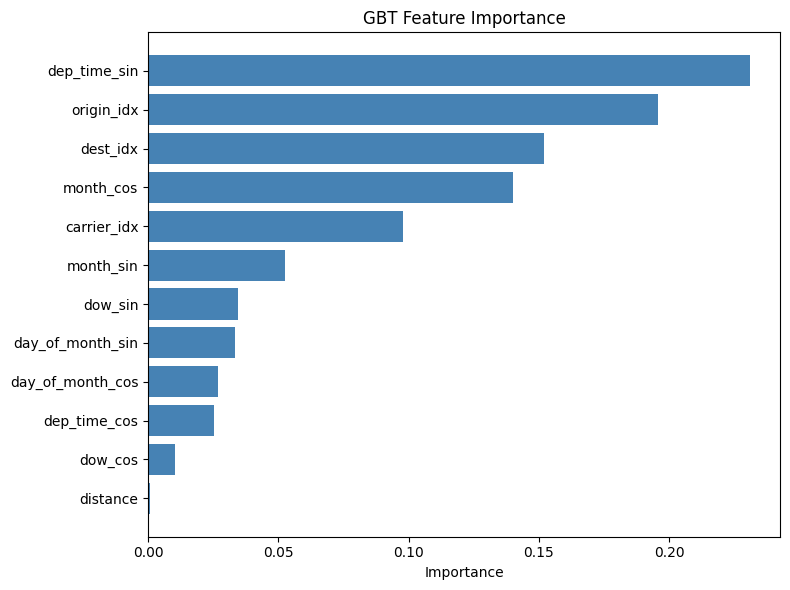

In [ ]:
# Feature importance
def plot_feature_importance(model, feature_cols, title):
    importances = model.stages[-1].featureImportances.toArray()
    fi_df = pd.DataFrame({"feature": feature_cols, "importance": importances})
    fi_df = fi_df.sort_values("importance", ascending=True)

    plt.figure(figsize=(8, 6))
    plt.barh(fi_df["feature"], fi_df["importance"], color="steelblue")
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/DSAI4202_Project/{title.replace(' ','_')}.png")
    plt.show()
plot_feature_importance(cv_model.bestModel, feature_cols, "GBT Feature Importance")

## Feature Importance Interpretation
- dep_time_sin was the single most important feature at around 0.23 importance
- origin_idx came second at around 0.20, showing some airports are more delay prone than others
- dest_idx was third at around 0.15, destination congestion also plays a role
- month_cos was fourth at around 0.14, confirming strong seasonal patterns
- carrier_idx contributed around 0.10, carrier operations quality varies significantly
- distance had near zero importance, flight length alone does not predict delays
- The cyclical encoding worked well since dep_time_sin being the top feature confirms departure time patterns are genuinely predictive

## Threshold tuning on GBT - no retraining

Thresh=0.10  Acc=0.2957  Prec=0.2218  Rec=0.9689  F1=0.3610
Thresh=0.15  Acc=0.4846  Prec=0.2637  Rec=0.8424  F1=0.4016
Thresh=0.20  Acc=0.6325  Prec=0.3134  Rec=0.6631  F1=0.4256
Thresh=0.25  Acc=0.7138  Prec=0.3590  Rec=0.5016  F1=0.4185
Thresh=0.30  Acc=0.7585  Prec=0.4017  Rec=0.3598  F1=0.3796
Thresh=0.35  Acc=0.7811  Prec=0.4434  Rec=0.2589  F1=0.3269
Thresh=0.40  Acc=0.7933  Prec=0.4897  Rec=0.1567  F1=0.2374
Thresh=0.45  Acc=0.7963  Prec=0.5226  Rec=0.0902  F1=0.1539
Thresh=0.50  Acc=0.7963  Prec=0.5323  Rec=0.0650  F1=0.1159
Thresh=0.55  Acc=0.7965  Prec=0.5585  Rec=0.0436  F1=0.0809
Thresh=0.60  Acc=0.7954  Prec=0.6199  Rec=0.0089  F1=0.0175
Thresh=0.65  Acc=0.7947  Prec=0.7778  Rec=0.0001  F1=0.0002
Thresh=0.70  Acc=0.7947  Prec=0.0000  Rec=0.0000  F1=0.0000
Thresh=0.75  Acc=0.7947  Prec=0.0000  Rec=0.0000  F1=0.0000
Thresh=0.80  Acc=0.7947  Prec=0.0000  Rec=0.0000  F1=0.0000
Thresh=0.85  Acc=0.7947  Prec=0.0000  Rec=0.0000  F1=0.0000


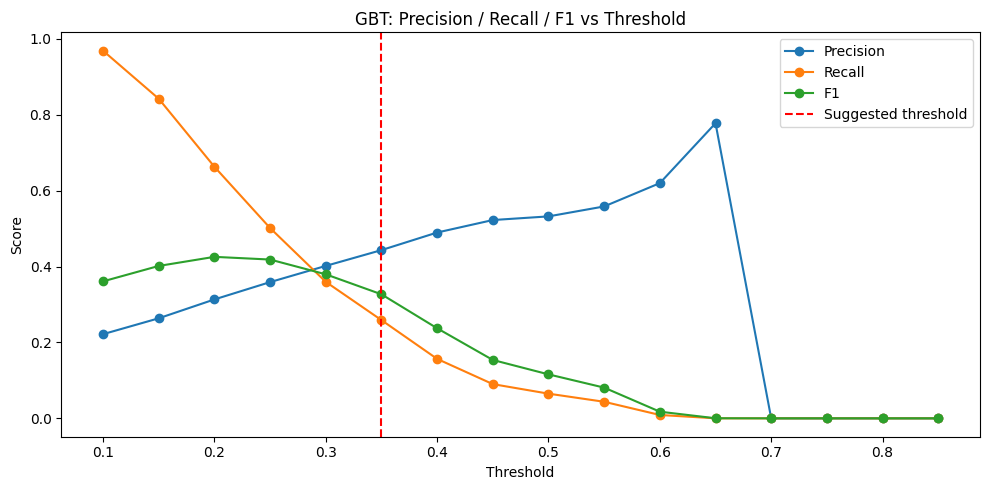

In [ ]:
extract_prob = udf(lambda v: float(v[1]), DoubleType())
pred_gbt_prob = pred_gbt.withColumn("prob_1", extract_prob(col("probability")))

# Try different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for thresh in thresholds:
    tmp = pred_gbt_prob.withColumn(
        "prediction", (col("prob_1") >= thresh).cast("double")
    )
    acc = evaluator_acc.evaluate(tmp)
    f1  = evaluator_f1.evaluate(tmp)
    tp = tmp.filter((col("prediction") == 1) & (col("label") == 1)).count()
    fp = tmp.filter((col("prediction") == 1) & (col("label") == 0)).count()
    fn = tmp.filter((col("prediction") == 0) & (col("label") == 1)).count()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_manual = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    results.append((round(thresh, 2), acc, f1, precision, recall, f1_manual))
    print(f"Thresh={thresh:.2f}  Acc={acc:.4f}  Prec={precision:.4f}  Rec={recall:.4f}  F1={f1_manual:.4f}")

# Plot
res_arr = np.array([(r[0], r[3], r[4], r[5]) for r in results])
plt.figure(figsize=(10, 5))
plt.plot(res_arr[:,0], res_arr[:,1], label="Precision", marker="o")
plt.plot(res_arr[:,0], res_arr[:,2], label="Recall",    marker="o")
plt.plot(res_arr[:,0], res_arr[:,3], label="F1",        marker="o")
plt.axvline(x=0.35, color="red", linestyle="--", label="Suggested threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("GBT: Precision / Recall / F1 vs Threshold")
plt.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/DSAI4202_Project/threshold_tuning.png")
plt.show()

## Threshold Tuning

- by default pyspark GBT uses 0.5 as the threshold to decide if a flight is delayed or not
- the problem is our dataset is imbalanced, only 20% of flights are delayed
- so the model naturally assigns low probabilities to the delayed class
- at 0.5 threshold the probability of most flights never even reaches 0.5 so the model barely ever predicts delayed
- that's why recall was only 0.065 at default, catching literally 1 in 15 real delays
- we need to lower the threshold so more flights get flagged as delayed

- at 0.10 we catch 96.9% of delays but precision is 0.22, basically flagging everything as delayed which is useless
- at 0.20 we get the best F1 of 0.4256, catching 66% of real delays, this is our chosen threshold
- after 0.20 recall drops really fast and F1 falls too so 0.20 is the sweet spot

- from 0.70 onwards the model stops predicting delayed completely, precision and recall both go 0
- accuracy stays at 0.7947 from 0.70 onwards but that's literally just predicting on time for everything, completely useless

- the whole point of threshold tuning is the business tradeoff
- if you're an airline you would rather send a few extra delay alerts than miss a real delay and have passengers show up on time to a delayed flight
- that's why we chose 0.20, it catches 2 out of every 3 real delays which is so much better than the default

- also accuracy at 0.10 looks terrible at 0.2957 but that's only because we flagging almost every flight as delayed
- so all the on time flights get wrongly classified, accuracy tanks but recall goes way up
- this is exactly why F1 score is the right metric to use here not accuracy

## FINAL CLEAN METRICS

In [ ]:
# Apply best threshold and get final clean metrics
best_thresh =  0.20

pred_final = pred_gbt_prob.withColumn(
    "prediction", (col("prob_1") >= best_thresh).cast("double")
)

tp = pred_final.filter((col("prediction") == 1) & (col("label") == 1)).count()
fp = pred_final.filter((col("prediction") == 1) & (col("label") == 0)).count()
tn = pred_final.filter((col("prediction") == 0) & (col("label") == 0)).count()
fn = pred_final.filter((col("prediction") == 0) & (col("label") == 1)).count()

precision = tp / (tp + fp)
recall    = tp / (tp + fn)
f1        = 2 * precision * recall / (precision + recall)
accuracy  = (tp + tn) / (tp + fp + tn + fn)

print(f"\n=== GBT @ threshold={best_thresh} ===")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1       : {f1:.4f}")
print(f"\n  Confusion Matrix:")
print(f"              Pred 0    Pred 1")
print(f"  Actual 0:   {tn:<8}  {fp}")
print(f"  Actual 1:   {fn:<8}  {tp}")


=== GBT @ threshold=0.2 ===
  Accuracy : 0.6325
  Precision: 0.3134
  Recall   : 0.6631
  F1       : 0.4256

  Confusion Matrix:
              Pred 0    Pred 1
  Actual 0:   165930    99708
  Actual 1:   23127     45512


## Final Metrics Understanding

- after threshold tuning at 0.20 the GBT model performance is much more balanced than before

- accuracy is 0.6325, lower than the default 0.7963 but this is expected
- accuracy drops because we now flagging more flights as delayed, so more on time flights get misclassified
- but this is a good tradeoff because we are actually catching real delays now

- precision of 0.3134 means out of every 10 flights we predict as delayed, about 3 are actually delayed
- this sounds low but given the 3.86 to 1 imbalance this is actually reasonable performance
- if the classes were balanced we would expect higher precision

- recall of 0.6631 is the big win here, we went from catching 6.5% of delays to catching 66.3%
- that's a 10x improvement just by changing the threshold, no retraining needed

- F1 of 0.4256 is the best we got across all thresholds and all models

- looking at the confusion matrix:
    - TN = 165930, we correctly identified 165,930 on time flights as on time
    - FP = 99708, we wrongly flagged 99,708 on time flights as delayed (false alarms)
    - FN = 23127, we missed 23,127 real delays (these are the dangerous ones)
    - TP = 45512, we correctly caught 45,512 real delays

- the FP count of 99,708 is high but in airline context a false alarm is less damaging than a missed delay
- missing 23,127 delays means those passengers got no warning at all
- catching 45,512 real delays means those passengers and airline staff got advance notice

- overall this is a practically useful model for real world delay prediction given the limited features we had

In [ ]:
# OVERFITTING / UNDERFITTING / BIAS-VARIANCE CHECK
print("=== Bias-Variance / Overfit Check ===\n")

for name, model, train_data, test_preds in [
    ("Logistic Regression", model_lr, train, pred_lr),
    ("Random Forest",       model_rf, train, pred_rf),
    ("GBT (untuned)",       model_gbt, train, pred_gbt),
    ("GBT (tuned)",           cv_model, train, pred_cv),
]:

    train_preds = model.transform(train)
    train_auc = evaluator_auc.evaluate(train_preds)
    test_auc  = evaluator_auc.evaluate(test_preds)
    gap = train_auc - test_auc

    if gap > 0.05:
        verdict = "OVERFITTING: train much better than test"
    elif test_auc < 0.60:
        verdict = "UNDERFITTING: model not learning enough"
    else:
        verdict = "OK"

    print(f"{name}")
    print(f"  Train AUC : {train_auc:.4f}")
    print(f"  Test AUC  : {test_auc:.4f}")
    print(f"  Gap       : {gap:.4f}  →  {verdict}\n")

=== Bias-Variance / Overfit Check ===

Logistic Regression
  Train AUC : 0.6531
  Test AUC  : 0.6519
  Gap       : 0.0013  →  OK

Random Forest
  Train AUC : 0.6695
  Test AUC  : 0.6674
  Gap       : 0.0020  →  OK

GBT (untuned)
  Train AUC : 0.7056
  Test AUC  : 0.6975
  Gap       : 0.0081  →  OK

GBT (tuned)
  Train AUC : 0.7056
  Test AUC  : 0.6975
  Gap       : 0.0081  →  OK



## Bias Variance Analysis

- overfitting is when the model does well on train data but badly on test data, gap above 0.05 indicates this
- underfitting is when the model doesn't learn enough, test AUC below 0.60 indicates this

- LR gap is only 0.0013, train and test AUC are basically identical, no overfitting at all
- RF gap is 0.0020, again almost no difference between train and test, generalizing well
- GBT untuned has the biggest gap at 0.0081 but this is still way below 0.05 so its fine
- GBT tuned has the exact same gap as untuned at 0.0081, tuning didn't cause any overfitting

- all 4 models have test AUC above 0.60 so no underfitting either
- the models are actually learning something useful from the data

- the small gaps make sense because we used a large dataset of 1.6 million rows
- with this much data it's hard for the model to memorize the training set
- also we used 80/20 split with seed 42 so the train and test sets are representative of the same distribution

- we decided these results are reassuring, the models generalize well and there is no sign of overfitting
- the problem isn't overfitting, the main challenge is the class imbalance and the limited features we have
- adding more features like weather data or historical delay rates would probably improve the AUC scores significantly

##  Feature Selection - ChiSqSelector

Note: Feature selection analysis is placed here at the end as a standalone
validation step. The purpose is to compare model performance with all 12
features versus the top 8 features selected by ChiSqSelector. This was done
after full model training and evaluation to avoid interfering with the main
pipeline and to use it as a post-hoc analysis to validate our feature
importance findings.

In [ ]:
from pyspark.ml.feature import ChiSqSelector
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler

temp_pipeline = Pipeline(stages=[
    carrier_indexer, origin_indexer, dest_indexer, assembler
])
temp_model = temp_pipeline.fit(train)
train_assembled = temp_model.transform(train)
test_assembled  = temp_model.transform(test)

selector = ChiSqSelector(
    numTopFeatures=8,
    featuresCol="features",
    outputCol="selectedFeatures",
    labelCol="label"
)
selector_model = selector.fit(train_assembled)
train_selected = selector_model.transform(train_assembled)
test_selected  = selector_model.transform(test_assembled)

print("Selected feature indices:", selector_model.selectedFeatures)
print("Selected features:")
for i in selector_model.selectedFeatures:
    print(f"  [{i}] {feature_cols[i]}")

Selected feature indices: [0, 1, 2, 3, 4, 5, 6, 7]
Selected features:
  [0] carrier_idx
  [1] origin_idx
  [2] dest_idx
  [3] distance
  [4] month_sin
  [5] month_cos
  [6] dow_sin
  [7] dow_cos


In [ ]:
# Retrain best model (GBT) on selected features only
gbt_fs = GBTClassifier(
    featuresCol="selectedFeatures", labelCol="label",
    maxIter=20, maxDepth=5, seed=42, maxBins=400
)
model_gbt_fs = gbt_fs.fit(train_selected)
pred_gbt_fs  = model_gbt_fs.transform(test_selected)

In [ ]:
# Compare metrics
auc_original = evaluator_auc.evaluate(pred_gbt)
auc_selected = evaluator_auc.evaluate(pred_gbt_fs)

acc_original = evaluator_acc.evaluate(pred_gbt)
acc_selected = evaluator_acc.evaluate(pred_gbt_fs)

f1_original = evaluator_f1.evaluate(pred_gbt)
f1_selected = evaluator_f1.evaluate(pred_gbt_fs)

print(f"{'Model':<30} {'AUC':>8} {'Accuracy':>10} {'F1':>8}")
print("-" * 58)
print(f"{'GBT (all 12 features)':<30} {auc_original:>8.4f} {acc_original:>10.4f} {f1_original:>8.4f}")
print(f"{'GBT (8 selected features)':<30} {auc_selected:>8.4f} {acc_selected:>10.4f} {f1_selected:>8.4f}")

Model                               AUC   Accuracy       F1
----------------------------------------------------------
GBT (all 12 features)            0.6975     0.7963   0.7270
GBT (8 selected features)        0.6411     0.7948   0.7055


## Feature Selection Insights
- ChiSqSelector selected top 8 features: carrier_idx, origin_idx, dest_idx, distance, month_sin, month_cos, dow_sin, dow_cos
- Dropped 4 features: day_of_month_sin, day_of_month_cos, dep_time_sin, dep_time_cos
- GBT retrained on 8 features gave AUC of 0.6411 vs 0.6975 with all 12 features
- This is a drop of 0.056 which is significant
- The drop is caused by removing dep_time_sin which was the most important feature in the GBT importance plot
- ChiSqSelector ranked dep_time_sin as unimportant but GBT relied on it heavily
- ChiSqSelector expects non-negative categorical features, so its ranking of the sine/cosine and continuous features here is not reliable
- Conclusion: the AUC drop shows the selected subset is worse, so all 12 features should be kept for best model performance

## Conclusion
- Best model: GBT with threshold 0.20, achieving F1 of 0.4256, Recall of 0.663, and AUC of 0.6975
- Most important features: departure time, origin airport, destination airport, and month
- Distance had near zero importance despite being a commonly assumed predictor of delays
- Class imbalance was the biggest challenge, without threshold tuning GBT caught under 7% of delays
- Retraining GBT on 8 features lowered AUC from 0.6975 to 0.6411, so all 12 features were kept; removing dep_time_sin dropped AUC by 0.056
- All models showed train-test AUC gaps under 0.01, confirming no overfitting
- Future work could include adding weather data, historical airport congestion scores, and monthly retraining

#### Recommendations

- Recommendation for airlines: use GBT with threshold 0.20 to get early delay warnings
- Recommendation for airports: focus on DFW and CLT which have the highest delay rates
- Recommendation for future work: add weather data and historical congestion features